In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
from pathlib import Path
import re

data_dir = Path("data_chest/chest_Xray")

# Exclusion des radiographies des patients avec une pneumonie mixte (bacteria + virus)

In [ ]:
from collections import defaultdict

patients_ambigus = set()
patient_pathologies = defaultdict(set)

for img_path in data_dir.rglob("*.jp*g"):
    filename = img_path.name.lower()
    
    # Extraction rapide de l'ID
    if "person" in filename:
        pid = re.match(r"(person\d+)", filename)
        pid = pid.group(1) if pid else None
    elif filename.startswith("im-"):
        pid = re.match(r"(im-\d+)", filename)
        pid = pid.group(1).upper() if pid else None
    else:
        pid = filename.split('_')[0].split('-')[0]
        
    if pid:
        if "bacteria" in filename:
            patient_pathologies[pid].add("BACTERIA")
        elif "virus" in filename:
            patient_pathologies[pid].add("VIRUS")

# On remplit le set des exclus
for pid, pathologies in patient_pathologies.items():
    if "BACTERIA" in pathologies and "VIRUS" in pathologies:
        patients_ambigus.add(pid)

print(f"ℹ️ {len(patients_ambigus)} patients ambigus (Bactérie + Virus) détectés de manière globale. Ils seront ignorés.")

ℹ️ 979 patients ambigus (Bactérie + Virus) détectés de manière globale. Ils seront ignorés.


In [ ]:

def extract_patient_ids(split_name):
    patient_ids = set()
    split_path = data_dir / split_name
    
    # On parcourt récursivement toutes les images (.jpeg ou .jpg) dans les sous-dossiers
    for img_path in split_path.rglob("*.jp*g"):
        filename = img_path.name
        
        # Cas 1 : Format "personXXX_..." (Pneumonie)
        if "person" in filename:
            match = re.match(r"(person\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 2 : Format "IM-XXXX-..." (cas Normaux : mais peut-être aussi ID d'images : on les identifie sans les supprimer)
        elif filename.startswith("IM-"):
            match = re.match(r"(IM-\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 3 : Sécurité si le format varie (on prend le premier bloc avant le premier tiret/underscore)
        else:
            fallback_id = filename.split('_')[0].split('-')[0]
            patient_ids.add(fallback_id)
            
    return patient_ids

# Extraction des IDs pour chaque groupe
train_patients = extract_patient_ids("train")
test_patients = extract_patient_ids("test")
val_patients = extract_patient_ids("val")

print(f"Nombre de patients uniques - Train: {len(train_patients)}, Test: {len(test_patients)}, Val: {len(val_patients)}")

# --- VERIFICATION DES INTERSECTIONS : fonction intersection()
leak_train_test = train_patients.intersection(test_patients)
leak_train_val = train_patients.intersection(val_patients)
leak_val_test = val_patients.intersection(test_patients)

print("\n--- Résultats de la vérification ---")
if leak_train_test:
    print(f"❌ FUITE DÉTECTÉE entre Train et Test ! ({len(leak_train_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_test)}")
else:
    print("✅ Pas de fuite entre Train et Test.")

if leak_train_val:
    print(f"❌ FUITE DÉTECTÉE entre Train et Val ! ({len(leak_train_val)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_val)}")
else:
    print("✅ Pas de fuite entre Train et Val.")

if leak_val_test:
    print(f"❌ FUITE DÉTECTÉE entre Val et Test ! ({len(leak_val_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_val_test)}")
else:
    print("✅ Pas de fuite entre Val et Test.")

Nombre de patients uniques - Train: 2154, Test: 268, Val: 8

--- Résultats de la vérification ---
❌ FUITE DÉTECTÉE entre Train et Test ! (171 patients en commun)
IDs corrompus : ['person138', 'person49', 'person80', 'person1668', 'person75', 'person141', 'person100', 'person1671', 'person1625', 'person30', 'person1660', 'person45', 'person86', 'person60', 'person158', 'person103', 'person1613', 'person161', 'person110', 'person131', 'person32', 'person69', 'person82', 'person89', 'person40', 'person151', 'person66', 'person31', 'person1615', 'person67', 'person125', 'person1670', 'person8', 'person55', 'person25', 'person11', 'person71', 'person1620', 'person39', 'person52', 'person1608', 'person128', 'person1616', 'person26', 'person65', 'person1635', 'person113', 'person1641', 'person1', 'person23', 'person34', 'person77', 'person1610', 'person22', 'person54', 'person35', 'person51', 'person3', 'person97', 'person137', 'person1643', 'person1682', 'person104', 'person1667', 'person15'

In [ ]:
# on isole les ID des patients à pneumonies mixtes (??)
patients_a_exclure = set(leak_train_test)
patients_a_exclure.discard("NORMAL2")

print(f"Nombre d'IDs de patients à filtrer : {len(patients_a_exclure)}")

# 2. Nettoyage des sets existants en soustrayant les exclus
# L'opérateur '-' retire du set de gauche tous les éléments présents dans le set de droite
train_patients_clean = train_patients - patients_a_exclure
test_patients_clean = test_patients - patients_a_exclure
val_patients_clean = val_patients - patients_a_exclure

print(f"\n--- Nombre de patients uniques APRÈS filtrage ---")
print(f"Train: {len(train_patients_clean)}, Test: {len(test_patients_clean)}, Val: {len(val_patients_clean)}")

Nombre d'IDs de patients à filtrer : 170

--- Nombre de patients uniques APRÈS filtrage ---
Train: 1984, Test: 98, Val: 8


## Dataframe de base "nettoyé"

In [ ]:
data_records = []

clean_splits = {
    "train": train_patients_clean,
    "test": test_patients_clean,
    "val": val_patients_clean
}

for split_name, clean_patients in clean_splits.items():
    split_path = data_dir / split_name
    
    for img_path in split_path.rglob("*.jp*g"):
        filename = img_path.name
        
        # On extrait l'ID
        if "person" in filename:
            match = re.match(r"(person\d+)", filename)
            pid = match.group(1) if match else None
        elif filename.startswith("IM-"):
            match = re.match(r"(IM-\d+)", filename)
            pid = match.group(1) if match else None
        else:
            pid = filename.split('_')[0].split('-')[0]
            
        # On ne garde l'image que si le patient fait partie du set nettoyé
        if pid in clean_patients:
            # On détermine le label (NORMAL, BACTERIA, VIRUS) basé sur le nom du fichier
            if "bacteria" in filename.lower():
                label = "BACTERIA"
            elif "virus" in filename.lower():
                label = "VIRUS"
            else:
                label = "NORMAL" # Les fichiers IM-XXXX ou sans mention
                
            # On enregistre les infos de l'image
            data_records.append({
                "path": str(img_path),
                "patient_id": pid,
                "label": label,
                "split": split_name
            })

df = pd.DataFrame(data_records)
print(f"✅ DataFrame créé avec succès ! Nombre total d'images conservées : {len(df)}")
print(df["split"].value_counts())

✅ DataFrame créé avec succès ! Nombre total d'images conservées : 5079
split
train    4759
test      304
val        16
Name: count, dtype: int64


In [107]:
df.head()

,path,patient_id,label,split
0,data_chest\chest_Xray\train\NORMAL\IM-0115-000...,IM-0115,NORMAL,train
1,data_chest\chest_Xray\train\NORMAL\IM-0117-000...,IM-0117,NORMAL,train
2,data_chest\chest_Xray\train\NORMAL\IM-0119-000...,IM-0119,NORMAL,train
3,data_chest\chest_Xray\train\NORMAL\IM-0122-000...,IM-0122,NORMAL,train
4,data_chest\chest_Xray\train\NORMAL\IM-0125-000...,IM-0125,NORMAL,train


In [108]:
df_counts = df.pivot_table(
    index="split", 
    columns="label", 
    values="patient_id", 
    aggfunc="nunique", 
    fill_value=0
)

print("📊 Nombre de PATIENTS UNIQUES par Split et par Label :")
display(df_counts)

📊 Nombre de PATIENTS UNIQUES par Split et par Label :


label,BACTERIA,NORMAL,VIRUS
split,,,
test,14,66,19
train,1246,519,1027
val,7,1,0


# Preprocessing des images

In [ ]:
import cv2

def preprocess_image(path, size=(130, 95), apply_clahe=False):
    """
    Charge une image, supprime les bordures noires et les lettres parasites,
    la passe en niveaux de gris, applique optionnellement CLAHE, et la redimensionne.
    """
    try:
        # Chargement de l'image en niveaux de gris directe avec OpenCV
        img_raw = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img_raw is None:
            raise ValueError("Impossible de charger l'image avec OpenCV.")

        # --- ÉTAPE A : SUPPRESSION DES BORDURES NOIRES ---
        # On crée un masque binaire des zones non-noires (seuil à 10 sur 255)
        _, thresh_crop = cv2.threshold(img_raw, 10, 255, cv2.THRESH_BINARY)
        # On trouve les contours de la cage thoracique
        contours, _ = cv2.findContours(thresh_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # On prend le plus grand contour qui est (normalement) la zone de la radio elle-même
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            # On rogne l'image sur ce contour
            img_processed = img_raw[y:y+h, x:x+w]
        else:
            img_processed = img_raw.copy()

        # --- ÉTAPE B : SUPPRESSION DES LETTRES PARASITES (L, R) ---
        # Les lettres et annotations sont généralement d'un blanc pur (proche de 255)
        # On crée un masque pour cibler ce blanc très intense
        _, text_mask = cv2.threshold(img_processed, 250, 255, cv2.THRESH_BINARY)
        
        # recommandé : On dilate légèrement le masque pour bien englober les bords des lettres
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        text_mask = cv2.dilate(text_mask, kernel, iterations=1)
        
        # On applique l'inpainting pour effacer le texte en le remplaçant par le voisinage direct
        img_processed = cv2.inpaint(img_processed, text_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

        # --- ÉTAPE C : CLAHE pour accentuer le contraste ---
        if apply_clahe:
            clip = 2.0
            grid = 8
            clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid))
            img_processed = clahe.apply(img_processed)

        # --- ÉTAPE D : REDIMENSIONNEMENT FINALE ---
        # OpenCV utilise (largeur, hauteur), donc (130, 95)
        img_resized = cv2.resize(img_processed, size, interpolation=cv2.INTER_AREA)

        # Normalisation finale par la division par 255
        return img_resized / 255.0

    except Exception as e:
        print(f"Erreur sur l'image {path} : {e}")
        return None

In [ ]:
# Visualisation des images avant / après prétraitement

def show_raw_and_processed(df, n=3, size=(130, 95), apply_clahe=False):
    """
    Affiche n images du dataset :
    - Ligne 1 : Image originale brute (RAW)
    - Ligne 2 : Image après preprocess_image (accepte False, True, ou "random")
    """
    # On s'assure de ne pas demander plus d'images que le DataFrame n'en contient
    n = min(n, len(df))

    plt.figure(figsize=(5 * n, 8))

    for i in range(n):
        row = df.iloc[i]
        path = row["path"]
        label = row["label"]

        # 1. Chargement de l'image originale brute
        img_raw = Image.open(path)

        # 2. Traitement 
        img_proc = preprocess_image(path, size=size, apply_clahe=apply_clahe)

        if img_proc is None:
            continue

        # Ligne 1 : Image brute (RAW)
        plt.subplot(2, n, i + 1)
        plt.imshow(img_raw, cmap="gray")
        plt.axis("off")
        plt.title(f"RAW\nLabel: {label}")

        # Ligne 2 : Image traitée (S'adapte automatiquement au mode choisi)
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(img_proc, cmap="gray")
        plt.axis("off")

        # Dynamisation du titre si le traitement est appliqué
        if apply_clahe is True:
            title_type = "PREPROCESSED (STANDARD CLAHE)"
        else:
            title_type = "PREPROCESSED (STANDARD)"

        plt.title(f"{title_type}\n{size[0]}×{size[1]}")

    plt.suptitle("Comparatif Images Brutes vs Prétraitées", fontsize=16)
    plt.tight_layout()
    plt.show()


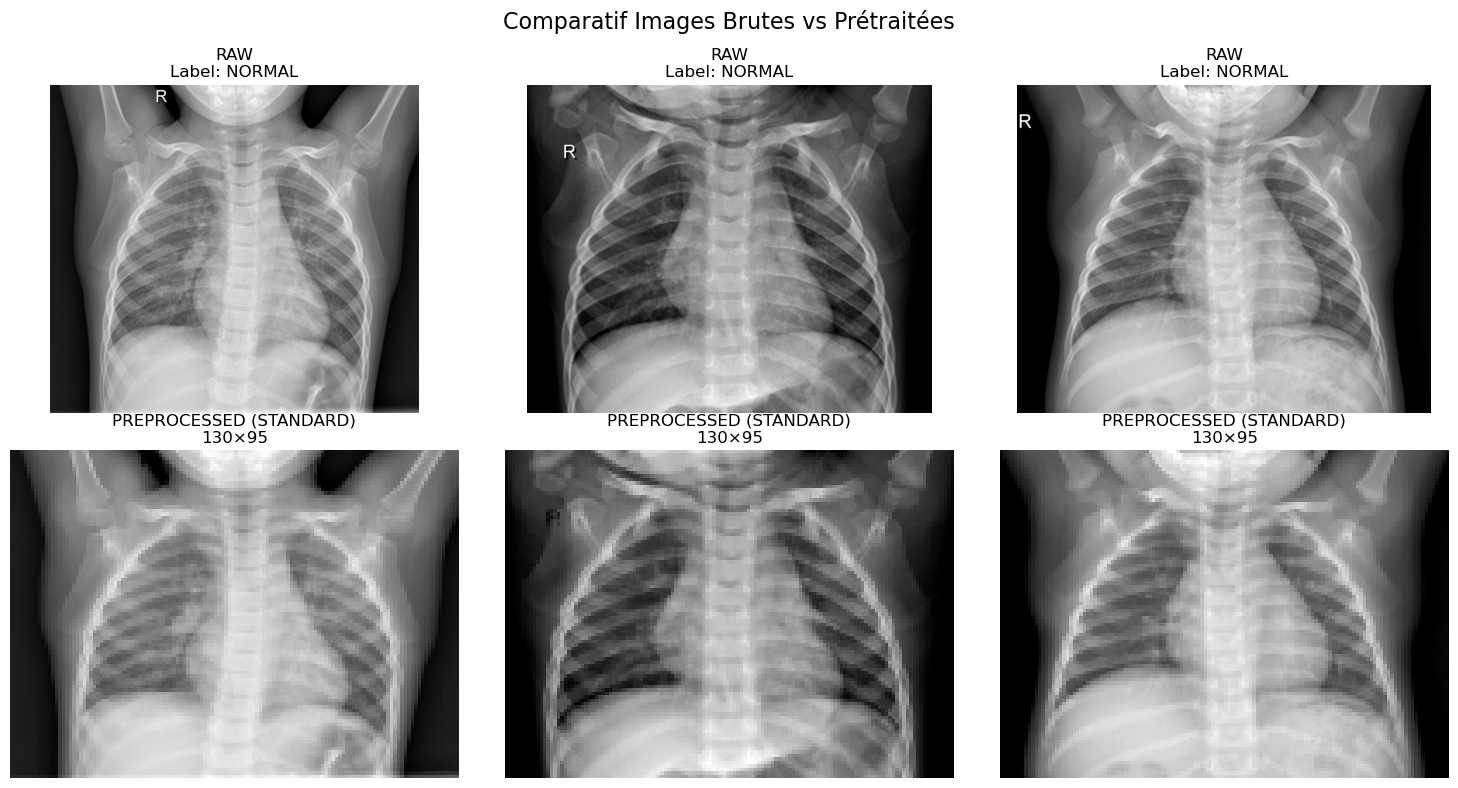

In [111]:
show_raw_and_processed(df[df["split"] == "train"], n=3, apply_clahe=False)

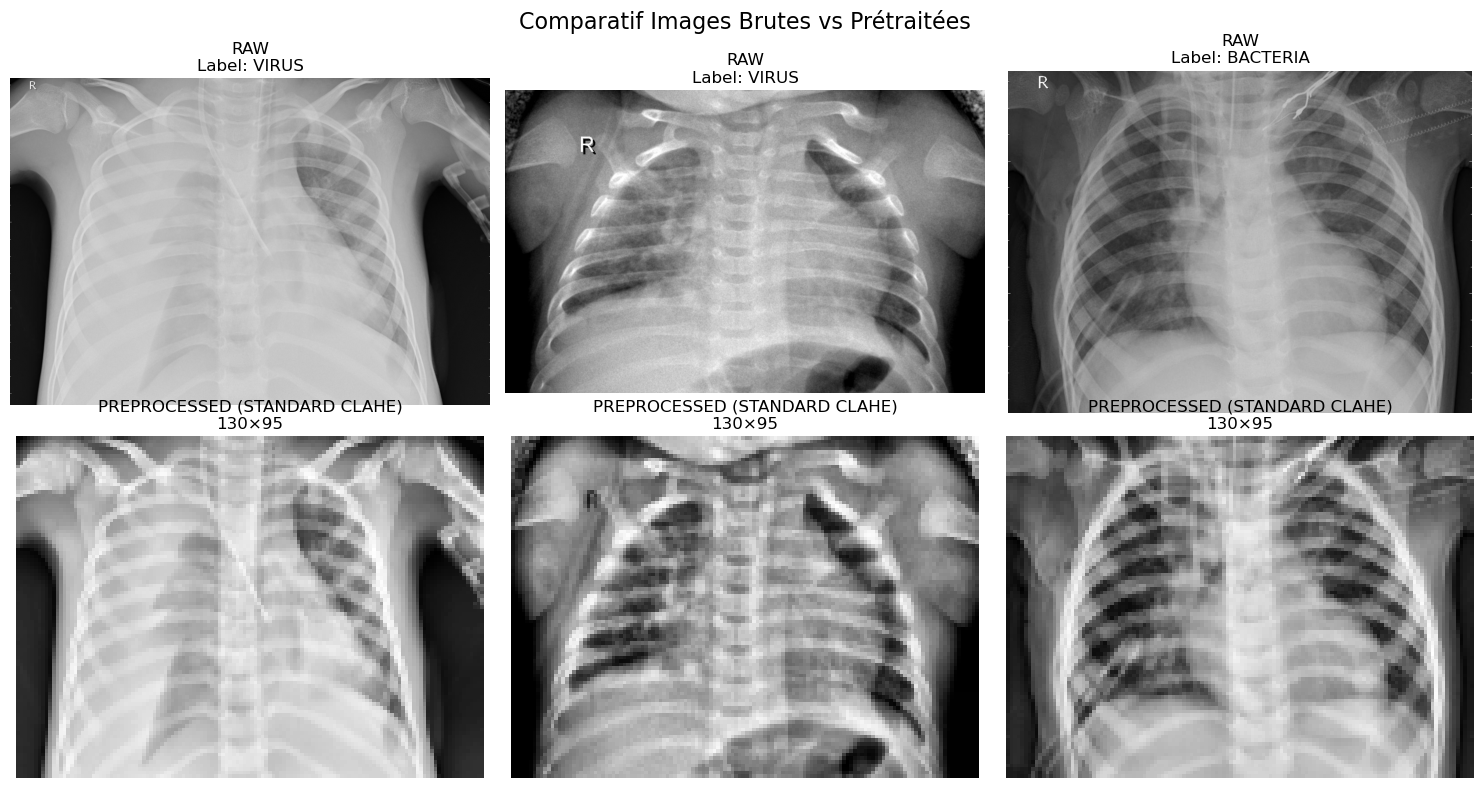

In [112]:
show_raw_and_processed((df[df["split"] == "train"]).sample(n=3), n=3, size=(130, 95), apply_clahe=True)

# Train-test-split

## Fusion datasets de train + valid

In [113]:
df_train = df[df["split"] == "train"]
df_val = df[df["split"] == "val"]

df_train_full = pd.concat([df_train, df_val], ignore_index=True)
df_train_full["split"] = "train"

In [114]:
len(df_train_full)

4775

## Train-test-split stratifié 80/20

In [115]:
# création du dataset de validation
from sklearn.model_selection import train_test_split

df_train, df_valid = train_test_split(
    df_train_full,
    test_size=0.2,
    stratify=df_train_full["label"],
    random_state=42
)

In [116]:
df_test = df[df["split"] == "test"]

print("Nb images dans le jeu de train :", len(df_train))
print("Nb images dans le jeu de valid:", len(df_valid))
print("Nb images dans le jeu de test :", len(df_test))

Nb images dans le jeu de train : 3820
Nb images dans le jeu de valid: 955
Nb images dans le jeu de test : 304


# Récupération des X (images) et y (étiquettes) pour chaque jeu

In [117]:
def build_dataset(df_subset, size=(130, 95), apply_clahe=False):
    label_mapping = {"NORMAL": 0, "BACTERIA": 1, "VIRUS": 2}
    y = (
        df_subset["label"]
        .map(label_mapping)
        .fillna(-1)
        .to_numpy(dtype=np.int64)
    )

    # Liste de matrices 2D, avec le prétraitement CLAHE activé
    X_list = [
        preprocess_image(p, size, apply_clahe=apply_clahe) for p in df_subset["path"]
    ]
    return np.array(X_list), y

In [118]:
X_test, y_test = build_dataset(df_test, apply_clahe=True)
X_train, y_train = build_dataset(df_train, apply_clahe=True)
X_valid, y_valid = build_dataset(df_valid, apply_clahe=True)

In [119]:
print(X_train[0:1], y_train[0:1])

[[[0.21176471 0.2        0.21568627 ... 0.20392157 0.15294118 0.10588235]
  [0.17254902 0.16862745 0.2        ... 0.16470588 0.11764706 0.06666667]
  [0.16470588 0.15294118 0.2        ... 0.14117647 0.08235294 0.02745098]
  ...
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]]] [0]


# Distribution des classes dans chaque jeu

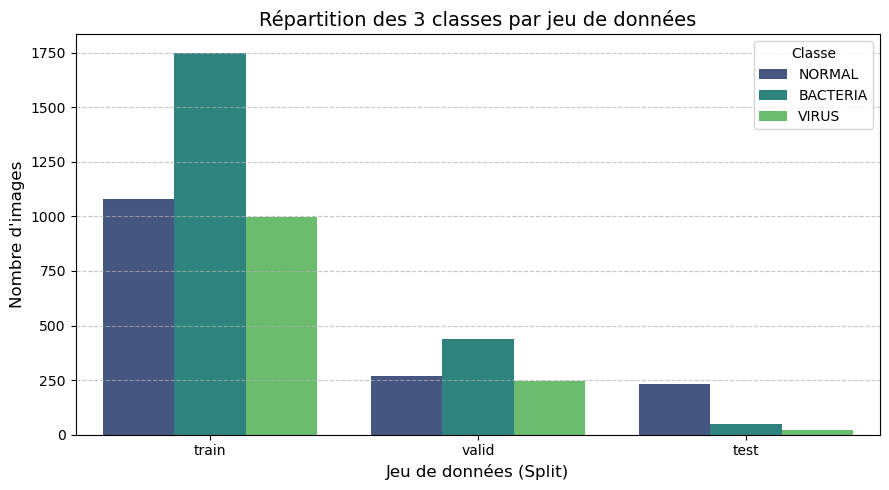

In [120]:
import seaborn as sns

classes = ["NORMAL", "BACTERIA", "VIRUS"]

# np.bincount compte les occurrences de 0, 1 et 2 d'un seul coup
df_counts = pd.DataFrame({
    "NORMAL":   [np.bincount(y_train)[0], np.bincount(y_valid)[0], np.bincount(y_test)[0]],
    "BACTERIA": [np.bincount(y_train)[1], np.bincount(y_valid)[1], np.bincount(y_test)[1]],
    "VIRUS":    [np.bincount(y_train)[2], np.bincount(y_valid)[2], np.bincount(y_test)[2]],
    "split":    ["train", "valid", "test"]
})

# 2. On reformate le DataFrame pour Seaborn (format "Long")
df_melted = df_counts.melt(id_vars="split", var_name="label", value_name="count")

# 3. Plot avec Seaborn
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_melted,
    x="split",
    y="count",
    hue="label",
    hue_order=classes,
    palette="viridis"
)

plt.title("Répartition des 3 classes par jeu de données", fontsize=14)
plt.xlabel("Jeu de données (Split)", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.legend(title="Classe")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Data Augmentation

## Effectifs actuels dans y_train

In [121]:
# --- ÉTAPE 1 : Analyser les  ---
counts = np.bincount(y_train)
nb_normal = counts[0]
nb_bacteria = counts[1]
nb_virus = counts[2]

target_count = nb_bacteria  # Classe majoritaire cible
print(f"Effectifs avant équilibrage -> NORMAL: {nb_normal}, BACTERIA: {nb_bacteria}, VIRUS: {nb_virus}")

Effectifs avant équilibrage -> NORMAL: 1079, BACTERIA: 1746, VIRUS: 995


## Rééquilibrage des classes sur le jeu de train

In [122]:
# utilisation de la focntion de preprocessing qui intègre CLAHE 
# pour rééquilibrer les classes 'NORMAL' et 'VIRUS' par rapport à 'BACTERIA' sur le jeu de train

# Listes pour stocker nos nouvelles images augmentées
X_augmented = []
y_augmented = []

# Pour la classe NORMAL
if nb_normal < target_count:
    needed = target_count - nb_normal
    # On isole les chemins des images "NORMAL" dans le DataFrame de train
    paths_normal = df_train[df_train["label"] == "NORMAL"]["path"].values
    # On tire au sort le nombre de chemins nécessaires
    chosen_paths = np.random.choice(paths_normal, size=needed, replace=True)
    
    # On applique la fonction  pour modifier le contraste à chaque itération
    for path in chosen_paths:
        img_clahe = preprocess_image(path, apply_clahe=True)
        if img_clahe is not None:
            X_augmented.append(img_clahe)
            y_augmented.append(0) # Label 0 pour NORMAL
    print(f"-> {needed} nouvelles images CLAHE aléatoires générées pour la classe NORMAL.")

# Pour la classe VIRUS
if nb_virus < target_count:
    needed = target_count - nb_virus
    paths_virus = df_train[df_train["label"] == "VIRUS"]["path"].values
    chosen_paths = np.random.choice(paths_virus, size=needed, replace=True)
    
    for path in chosen_paths:
        img_clahe = preprocess_image(path, apply_clahe=True)
        if img_clahe is not None:
            X_augmented.append(img_clahe)
            y_augmented.append(2) # Label 2 pour VIRUS
    print(f"-> {needed} nouvelles images CLAHE aléatoires générées pour la classe VIRUS.")


-> 667 nouvelles images CLAHE aléatoires générées pour la classe NORMAL.
-> 751 nouvelles images CLAHE aléatoires générées pour la classe VIRUS.


## Fusion avec le X_train et le y_train existants

In [123]:
# On transforme la liste d'images augmentées en tableau NumPy
X_aug_array = np.array(X_augmented)
y_aug_array = np.array(y_augmented)
    
# On ajoute ces nouvelles images à la suite de tes tableaux de base
X_train_balanced = np.concatenate([X_train, X_aug_array], axis=0)
y_train_balanced = np.concatenate([y_train, y_aug_array], axis=0)

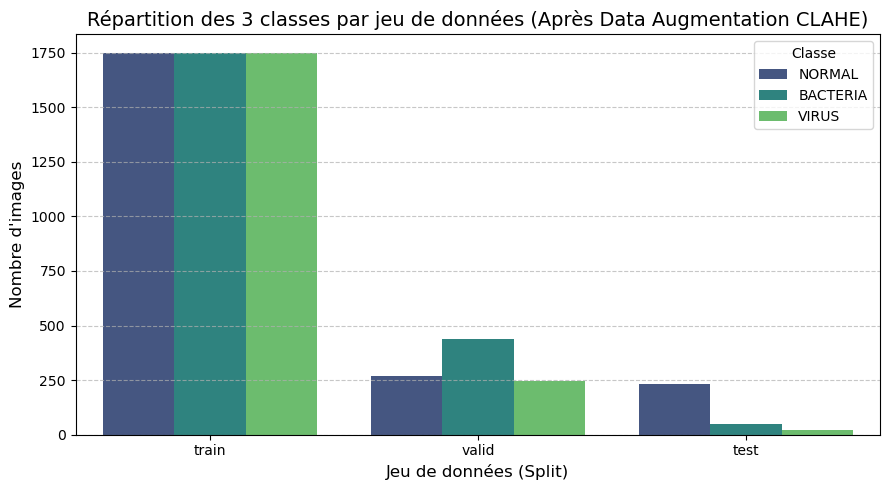

In [124]:
classes = ["NORMAL", "BACTERIA", "VIRUS"]

# On utilise y_train_balanced à la place de y_train
df_counts = pd.DataFrame(
    {
        "NORMAL": [
            np.bincount(y_train_balanced)[0],
            np.bincount(y_valid)[0],
            np.bincount(y_test)[0],
        ],
        "BACTERIA": [
            np.bincount(y_train_balanced)[1],
            np.bincount(y_valid)[1],
            np.bincount(y_test)[1],
        ],
        "VIRUS": [
            np.bincount(y_train_balanced)[2],
            np.bincount(y_valid)[2],
            np.bincount(y_test)[2],
        ],
        "split": ["train", "valid", "test"],
    }
)

# 2. Reformatage du DataFrame pour Seaborn (format "Long")
df_melted = df_counts.melt(id_vars="split", var_name="label", value_name="count")

# 3. Création du diagramme en barres
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_melted, x="split", y="count", hue="label", hue_order=classes, palette="viridis"
)

# Personnalisation des axes et titres
plt.title(
    "Répartition des 3 classes par jeu de données (Après Data Augmentation CLAHE)",
    fontsize=14,
)
plt.xlabel("Jeu de données (Split)", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.legend(title="Classe")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# CLASSIFICATION CLASSES 'NORMAL' VS 'BACTERIA' VS 'VIRUS'

## Recherche hyperparamètres RFC

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, roc_auc_score

In [126]:
# Aplanissement en vecteur 1D pour le Random Forest des 3 jeux
X_train_original = X_train.reshape(X_train.shape[0], -1)
X_train_flat = X_train_balanced.reshape(X_train_balanced.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# pour optimiser le roc_auc_score : Cross validation uniquement sur le train original
# pour éviter que des images augmentées (qui sont des variantes de celles du train) ne soient utilisées dans le même fold que l'orginale
param_grid = {
    'n_estimators': [30, 50, 100, 300, 500],
    'max_depth': [3, 5, 10, 20, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 5. Configurer la recherche pour optimiser le ROC AUC Multiclasse
grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50, 
    cv=5,              
    scoring='roc_auc_ovr',        # RECHERCHE BASEE SUR ROC AUC (One-vs-Rest)
    verbose=0
)

# Lancement de la recherche
grid_search.fit(X_train_flat, y_train_balanced)

print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur ROC AUC score  : {grid_search.best_score_:.4f}")


Meilleurs hyperparamètres : {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 30}
Meilleur ROC AUC sur le jeu de validation : 0.9741


In [128]:
rfc = grid_search.best_estimator_

In [129]:
# utilisation du train augmenté pour le fit final avec les meilleurs hyperparamètres trouvés
rfc.fit(X_train_flat, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Features les + importantes pour le modèle

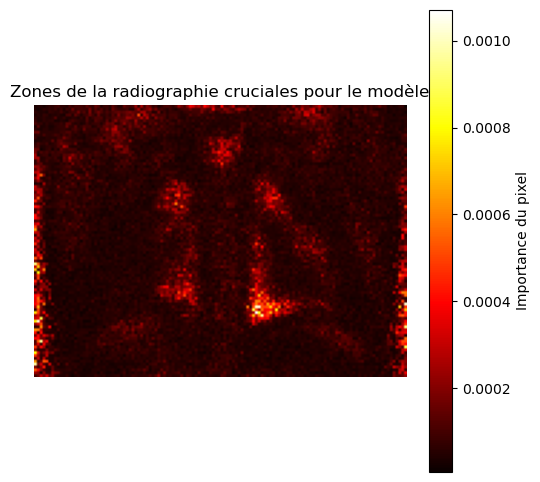

In [130]:
import seaborn as sns

# 1. Récupérer les scores d'importance depuis ton modèle entraîné
importances = rfc.feature_importances_

taille_image = (95, 130)  

# Re-transformer le vecteur en une matrice 2D
heatmap_importance = importances.reshape(taille_image)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap_importance, cmap='hot')
plt.colorbar(label='Importance du pixel')
plt.title("Zones de la radiographie cruciales pour le modèle")
plt.axis('off')
plt.show()

# Performances jeu de train

In [131]:
y_pred_train = rfc.predict(X_train_flat)

In [132]:
y_pred_proba_train = rfc.predict_proba(X_train_flat)

In [133]:
# ROC-AUC
roc_auc = roc_auc_score(
    y_train_balanced, 
    y_pred_proba_train,
    multi_class="ovr")

print(f"ROC-AUC (train) : {roc_auc:.3f}")

ROC-AUC (train) : 1.000


In [134]:
from sklearn.metrics import classification_report

print(classification_report(
        y_train_balanced,
        y_pred_train,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00      1746
    BACTERIA       1.00      1.00      1.00      1746
       VIRUS       1.00      1.00      1.00      1746

    accuracy                           1.00      5238
   macro avg       1.00      1.00      1.00      5238
weighted avg       1.00      1.00      1.00      5238



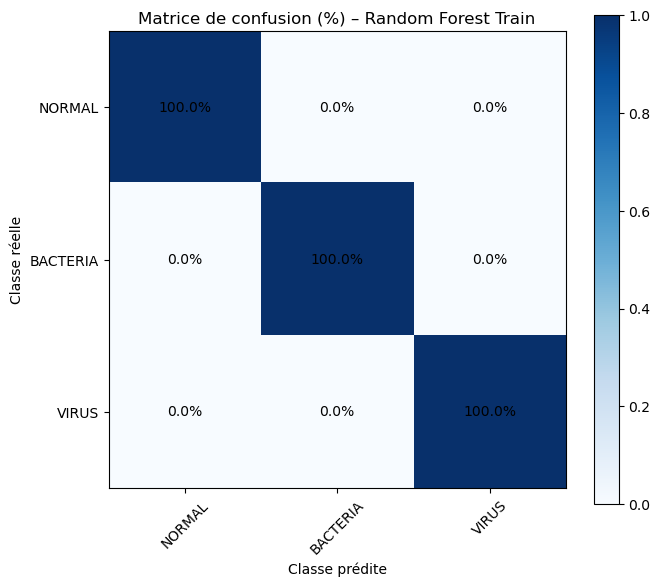

In [135]:
from sklearn.metrics import confusion_matrix

# Matrice de confusion
cm_train = confusion_matrix(y_train_balanced, y_pred_train)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_train.astype(float) / cm_train.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Train")

plt.tight_layout()
plt.show()

In [136]:
# Sur le jeu de train

class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_train[i,j]}"
        )

Réel=NORMAL, Prédit=NORMAL : 1746
Réel=NORMAL, Prédit=BACTERIA : 0
Réel=NORMAL, Prédit=VIRUS : 0
Réel=BACTERIA, Prédit=NORMAL : 0
Réel=BACTERIA, Prédit=BACTERIA : 1746
Réel=BACTERIA, Prédit=VIRUS : 0
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 0
Réel=VIRUS, Prédit=VIRUS : 1746


In [137]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for classe, nom in enumerate(class_names):

    TP = cm_train[classe, classe]

    FN = cm_train[classe, :].sum() - TP

    FP = cm_train[:, classe].sum() - TP

    TN = cm_train.sum() - TP - FN - FP

    print(f"\n--- {nom} vs reste ---")
    print(f"TP : {TP}")
    print(f"FP : {FP}")
    print(f"FN : {FN}")
    print(f"TN : {TN}")


--- NORMAL vs reste ---
TP : 1746
FP : 0
FN : 0
TN : 3492

--- BACTERIA vs reste ---
TP : 1746
FP : 0
FN : 0
TN : 3492

--- VIRUS vs reste ---
TP : 1746
FP : 0
FN : 0
TN : 3492


# Performances jeu de validation

In [138]:
y_pred_valid = rfc.predict(X_valid_flat)
y_pred_proba_valid = rfc.predict_proba(X_valid_flat)

In [139]:
roc_auc = roc_auc_score(
    y_valid, 
    y_pred_proba_valid,
    multi_class="ovr") # capacité globale du modèle à séparer les 3 classes, indépendamment du seuil

print(f"ROC-AUC (valid) : {roc_auc:.3f}")

ROC-AUC (valid) : 0.899


In [140]:
print(classification_report(
        y_valid,
        y_pred_valid,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))


              precision    recall  f1-score   support

      NORMAL       0.83      0.95      0.89       270
    BACTERIA       0.76      0.82      0.79       437
       VIRUS       0.68      0.48      0.56       248

    accuracy                           0.77       955
   macro avg       0.76      0.75      0.75       955
weighted avg       0.76      0.77      0.76       955



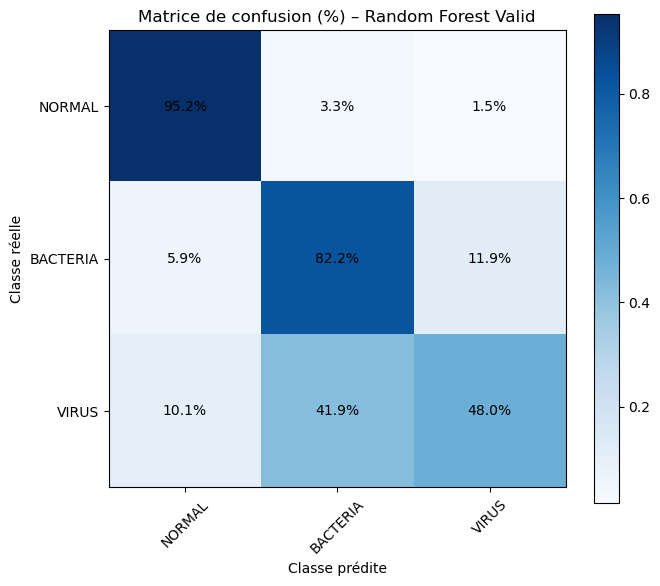

In [141]:
# Matrice de confusion
cm_valid = confusion_matrix(y_valid, y_pred_valid)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_valid.astype(float) / cm_valid.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Valid")

plt.tight_layout()
plt.show()

In [142]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_valid[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 257
Réel=NORMAL, Prédit=BACTERIA : 9
Réel=NORMAL, Prédit=VIRUS : 4
Réel=BACTERIA, Prédit=NORMAL : 26
Réel=BACTERIA, Prédit=BACTERIA : 359
Réel=BACTERIA, Prédit=VIRUS : 52
Réel=VIRUS, Prédit=NORMAL : 25
Réel=VIRUS, Prédit=BACTERIA : 104
Réel=VIRUS, Prédit=VIRUS : 119


In [143]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for classe, nom in enumerate(class_names):

    TP = cm_valid[classe, classe]

    FN = cm_valid[classe, :].sum() - TP

    FP = cm_valid[:, classe].sum() - TP

    TN = cm_valid.sum() - TP - FN - FP

    print(f"\n--- {nom} vs reste ---")
    print(f"TP : {TP}")
    print(f"FP : {FP}")
    print(f"FN : {FN}")
    print(f"TN : {TN}")


--- NORMAL vs reste ---
TP : 257
FP : 51
FN : 13
TN : 634

--- BACTERIA vs reste ---
TP : 359
FP : 113
FN : 78
TN : 405

--- VIRUS vs reste ---
TP : 119
FP : 56
FN : 129
TN : 651


# Essai avec un seuil de décision pour classification : sur le jeu de validation

## Seuils pour maximiser la détection des NORMAL vs PNEUMONIE, puis BACTERIA vs VIRUS

### Scénario 1 : limiter au maximum les FN pour la catégorie NORMAL

In [144]:
proba_valid_normal = y_pred_proba_valid[:, 0] # Probabilité d'être NORMAL selon le modèle
proba_valid_bacteria = y_pred_proba_valid[:, 1] # Probabilité d'être BACTERIE selon le modèle
proba_valid_virus = y_pred_proba_valid[:, 2] # Probabilité d'être VIRUS selon le modèle

# 1. On isole la probabilité globale d'être MALADE (Bacteria ou Virus)
# C'est l'inverse de la probabilité d'être sain (Normal)
proba_valid_malade = 1 - proba_valid_normal

In [145]:
thresholds = np.linspace(0.05, 0.95, 300)
rows = []
#la classe d'intérêt (1 / True / Positive) correspond aux PNEUMONIES.
# Donc tout ce qui n'est pas NORMAL (différent de 0) devient True.
y_valid_malade = (y_valid != 0)

for t in thresholds:
    y_pred = (proba_valid_malade >= t).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_valid_malade, y_pred).ravel()

    rows.append({
        "threshold": t,
        "FN": FN,
        "FP": FP,
        "recall": TP / (TP + FN),
        "fpr": FP / (FP + TN) # faux positifs / total des vrais négatifs
    })

df_thresh = pd.DataFrame(rows)

In [146]:
df_thresh.head()

,threshold,FN,FP,recall,fpr
0,0.05000,0,270,1.0,1.000000
1,0.05301,0,270,1.0,1.000000
2,0.05602,0,270,1.0,1.000000
3,0.05903,0,270,1.0,1.000000
4,0.06204,0,268,1.0,0.992593


In [147]:
print(df_thresh["recall"].min())
print(df_thresh["recall"].max())
print(df_thresh["fpr"].min())
print(df_thresh["fpr"].max())

0.3708029197080292
1.0
0.0
1.0


### Scénario 1 : limiter au maximum les FN pour la catégorie VIRUS

In [148]:
df_sc1 = df_thresh[
    (df_thresh["recall"] >= 0.98)
]

In [149]:
best_row_sc1 = (
    df_sc1
    .query(f"fpr <= {df_sc1['fpr'].min()}")
    .sort_values("FN")        
    .iloc[0]
)

print(best_row_sc1)

threshold     0.480435
FN           12.000000
FP           45.000000
recall        0.982482
fpr           0.166667
Name: 143, dtype: float64


In [150]:
best_threshold_sc1 = best_row_sc1["threshold"]

best_threshold_sc1

np.float64(0.48043478260869565)

### Scénario 2 : Limiter les FN sans trop pénaliser les FP : indice de Younden

In [151]:
#TROUVER LES MEILLEURS SEUILS POUR CHAQUE CLASSE
from sklearn.metrics import roc_curve

best_thresholds = {}

class_indices = [0, 1, 2]

# 2. Boucler sur chaque classe pour trouver son seuil optimal
for i, class_name in zip(class_indices, class_names):
    # Créer un y_valid binaire pour la classe en cours (1 si c'est la classe, 0 sinon)
    y_valid_binary = (y_valid == i).astype(int)
    
    # Récupérer les probabilités pour cette classe spécifique
    scores_for_class = y_pred_proba_valid[:, i]
    
    # Calculer la courbe ROC
    fpr, tpr, thresholds = roc_curve(y_valid_binary, scores_for_class)
    
    # Calculer l'indice de Youden pour chaque seuil
    youden_index = tpr - fpr

    # PIÈGE : On ignore le tout premier seuil (index 0) s'il vaut l'infini
    if thresholds[0] == np.inf or np.isinf(thresholds[0]):
        # On force l'indice de Youden du seuil infini à -1 pour l'éliminer
        youden_index[0] = -1
    
    # Trouver l'index du score maximum
    idx_optimal = np.argmax(youden_index)
    
    # Stocker le meilleur seuil
    best_thresholds[class_name] = thresholds[idx_optimal]

print("Seuils optimaux par classe :", best_thresholds)

Seuils optimaux par classe : {'NORMAL': np.float64(0.422), 'BACTERIA': np.float64(0.354), 'VIRUS': np.float64(0.3295)}


In [152]:
best_threshold_sc2 = best_thresholds['NORMAL']

best_threshold_sc2

np.float64(0.422)

In [153]:
stop;[|%\

SyntaxError: invalid syntax (143775823.py, line 1)

## Performances jeu de test sans seuil

In [154]:
y_pred= rfc.predict(X_test_flat)
y_pred_proba_test = rfc.predict_proba(X_test_flat)

In [155]:
print(y_pred_proba_test)

[[0.43       0.318      0.252     ]
 [0.434      0.31       0.256     ]
 [0.38       0.36371429 0.25628571]
 [0.268      0.42       0.312     ]
 [0.346      0.362      0.292     ]
 [0.424      0.304      0.272     ]
 [0.554      0.25       0.196     ]
 [0.378      0.316      0.306     ]
 [0.244      0.42       0.336     ]
 [0.372      0.402      0.226     ]
 [0.5        0.278      0.222     ]
 [0.34       0.378      0.282     ]
 [0.464      0.336      0.2       ]
 [0.49       0.256      0.254     ]
 [0.402      0.324      0.274     ]
 [0.438      0.264      0.298     ]
 [0.19595745 0.538      0.26604255]
 [0.444      0.358      0.198     ]
 [0.544      0.23       0.226     ]
 [0.506      0.238      0.256     ]
 [0.35       0.376      0.274     ]
 [0.44       0.262      0.298     ]
 [0.442      0.326      0.232     ]
 [0.484      0.3019863  0.2140137 ]
 [0.392      0.276      0.332     ]
 [0.498      0.25       0.252     ]
 [0.336      0.334      0.33      ]
 [0.362      0.4        0.23

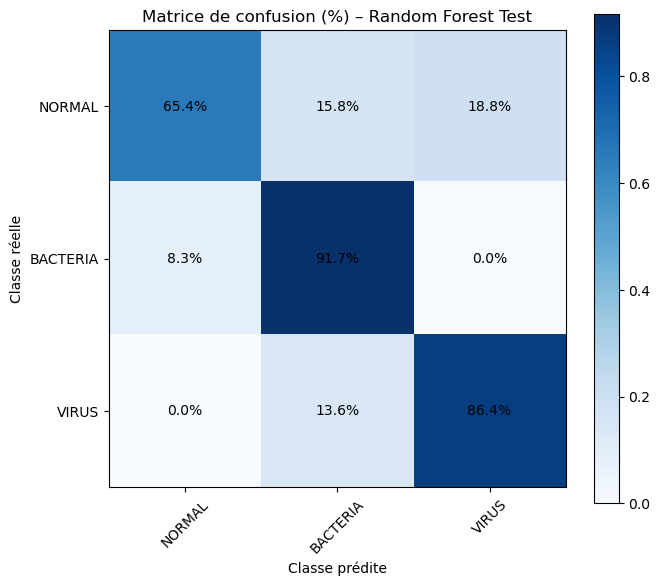

In [156]:
# Matrice de confusion
cm_test = confusion_matrix(y_test, y_pred)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test")

plt.tight_layout()
plt.show()

In [157]:
roc_auc = roc_auc_score(
    y_test, 
    y_pred_proba_test,
    multi_class="ovr") # capacité globale du modèle à séparer les 3 classes, indépendamment du seuil

print(f"ROC-AUC (test) : {roc_auc:.3f}")

ROC-AUC (test) : 0.932


In [158]:
print(classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))


              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.78       234
    BACTERIA       0.52      0.92      0.67        48
       VIRUS       0.30      0.86      0.45        22

    accuracy                           0.71       304
   macro avg       0.60      0.81      0.63       304
weighted avg       0.85      0.71      0.74       304



In [159]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_test[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 153
Réel=NORMAL, Prédit=BACTERIA : 37
Réel=NORMAL, Prédit=VIRUS : 44
Réel=BACTERIA, Prédit=NORMAL : 4
Réel=BACTERIA, Prédit=BACTERIA : 44
Réel=BACTERIA, Prédit=VIRUS : 0
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 3
Réel=VIRUS, Prédit=VIRUS : 19


## Performances jeu de test avec seuil

In [160]:
# classement "en cascade" des prédictions en fonction des seuils des 2 scénarios
# d'abord on applique le seuil optimisé pour la distinction NORMAL/MALADE, 
# puis on reclassifie BACTERIA et VIRUS avec les seuils optimaux respectifs

def predict_cascade(y_prob_matrix, thresh_malade, thresh_bacteria, thresh_virus):
    """
    y_prob_matrix : probabilités de predict_proba() [NORMAL, BACTERIA, VIRUS]
    thresh_malade : seuil de détection de la maladie (Scénario 1 ou Youden)
    thresh_bacteria : seuil Youden pour BACTERIA
    thresh_virus : seuil Youden pour VIRUS
    """
    final_predictions = []
    
    for probs in y_prob_matrix:
        # 1. On calcule le risque d'être malade
        prob_malade = 1 - probs[0] 
        
        # ÉTAPE 1 : Si le risque de maladie dépasse notre seuil de sécurité
        if prob_malade >= thresh_malade:
            
            # ÉTAPE 2 : Le patient est malade. On utilise les seuils Youden pour Bacteria vs Virus
            score_bacteria = probs[1] / (thresh_bacteria if thresh_bacteria > 0 else 1e-6)
            score_virus = probs[2] / (thresh_virus if thresh_virus > 0 else 1e-6)
            
            if score_bacteria > score_virus:
                final_predictions.append(1) # Prédit BACTERIA
            else:
                final_predictions.append(2) # Prédit VIRUS
        else:
            # Le risque est trop faible, le patient est sain
            final_predictions.append(0) # Prédit NORMAL
            
    return np.array(final_predictions)

### Scénario 1

In [161]:
y_pred_sc1 = predict_cascade(
    y_pred_proba_test, 
    thresh_malade=best_threshold_sc1,
    thresh_bacteria=1,                 # On met 1 pour ne pas modifier le score brut
    thresh_virus=1)

In [162]:
cm_sc1 = confusion_matrix(y_test, y_pred_sc1)

print(f"Seuil utilisé : {best_threshold_sc1}")

print(classification_report(
        y_test,
        y_pred_sc1,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

Seuil utilisé : 0.48043478260869565
              precision    recall  f1-score   support

      NORMAL       0.98      0.26      0.41       234
    BACTERIA       0.35      0.98      0.51        48
       VIRUS       0.18      0.86      0.29        22

    accuracy                           0.42       304
   macro avg       0.50      0.70      0.41       304
weighted avg       0.83      0.42      0.42       304



In [163]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_sc1[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 61
Réel=NORMAL, Prédit=BACTERIA : 85
Réel=NORMAL, Prédit=VIRUS : 88
Réel=BACTERIA, Prédit=NORMAL : 1
Réel=BACTERIA, Prédit=BACTERIA : 47
Réel=BACTERIA, Prédit=VIRUS : 0
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 3
Réel=VIRUS, Prédit=VIRUS : 19


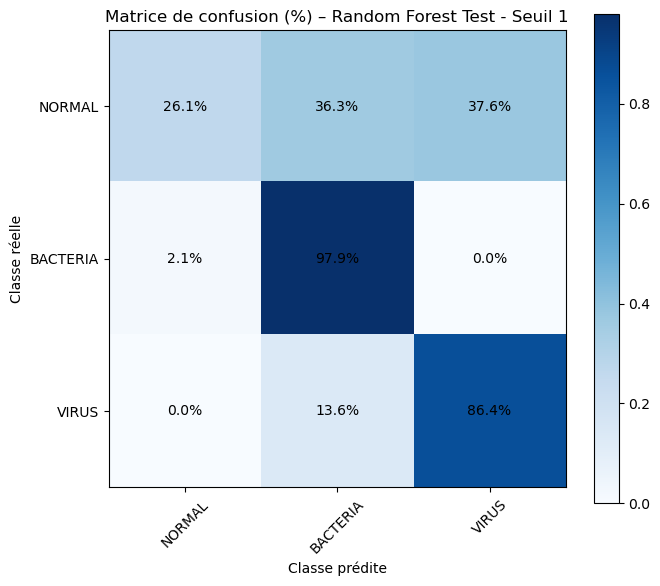

In [164]:
# Normalisation par ligne (classe réelle)
cm_normalized = cm_sc1.astype(float) / cm_sc1.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test - Seuil 1")

plt.tight_layout()
plt.show()

### Scénario 2

In [165]:
seuil_maladie_youden = 1 - best_thresholds['NORMAL']

y_pred_sc2 = predict_cascade(
    y_pred_proba_test, 
    thresh_malade=seuil_maladie_youden,       # Seuil Youden converti en risque maladie
    thresh_bacteria=best_thresholds['BACTERIA'], # Seuil Youden Bacteria
    thresh_virus=best_thresholds['VIRUS']        # Seuil Youden Virus
)

In [166]:
cm_sc2 = confusion_matrix(y_test, y_pred_sc2)

print(f"Seuil utilisé : {best_threshold_sc2}")

print(classification_report(
        y_test,
        y_pred_sc2,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

Seuil utilisé : 0.422
              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
    BACTERIA       0.47      0.94      0.63        48
       VIRUS       0.25      0.95      0.40        22

    accuracy                           0.62       304
   macro avg       0.57      0.81      0.57       304
weighted avg       0.85      0.62      0.66       304



In [167]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_sc2[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 123
Réel=NORMAL, Prédit=BACTERIA : 49
Réel=NORMAL, Prédit=VIRUS : 62
Réel=BACTERIA, Prédit=NORMAL : 2
Réel=BACTERIA, Prédit=BACTERIA : 45
Réel=BACTERIA, Prédit=VIRUS : 1
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 1
Réel=VIRUS, Prédit=VIRUS : 21


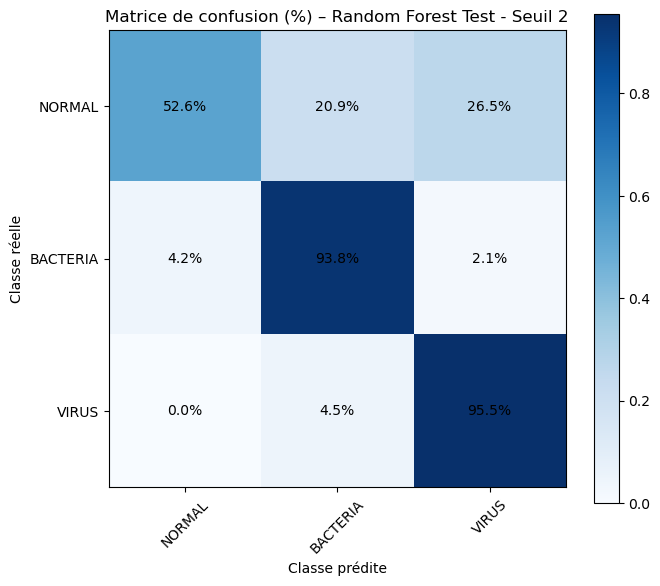

In [168]:
# Normalisation par ligne (classe réelle)
cm_normalized = cm_sc2.astype(float) / cm_sc2.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test - Seuil 2")

plt.tight_layout()
plt.show()

# Quelles images sont encore des FN ?

In [169]:
df_test = df[df["split"] == "test"].reset_index(drop=True)

fn_idx = np.where((y_test != 0) & (y_pred == 0))[0]

In [170]:
def show_errors(df_test, fn_indices, max_images=10):
    n = min(len(fn_indices), max_images)

    plt.figure(figsize=(15, 4 * ((n + 3) // 4)))

    for i, idx in enumerate(fn_indices[:n]):
        img_path = df_test.loc[idx, "path"]
        label = df_test.loc[idx, "label"]
        patient_id = df_test.loc[idx, "patient_id"]

        img = Image.open(img_path).convert("L")

        plt.subplot((n + 3) // 4, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"FN – {label}\nPatient ID: {patient_id}")

    plt.suptitle("Faux négatifs (cas de PNEUMONIA prédit NORMAL)", fontsize=16)
    plt.tight_layout()
    plt.show()


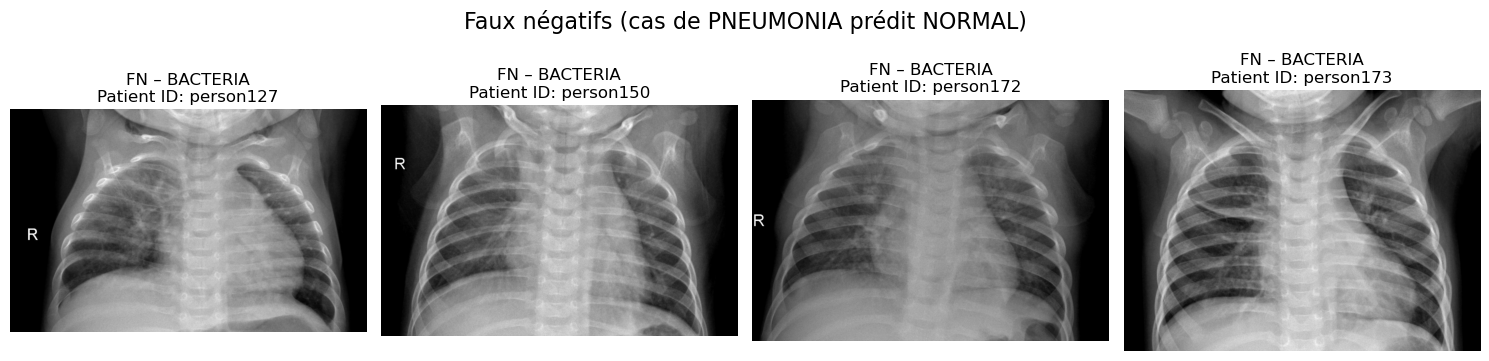

In [171]:
show_errors(df_test, fn_idx, max_images=10)
